<h1 align="center"><b>Pneumonia Detection in Chest X-Rays: Custom CNN vs. ResNet</b></h1>

# **Part A - MLPs vs CNNs**

## **1) Import Libraries and Setup**

All relevant libraries are imported below. Set your device to GPU/MPS if available. (Do not make any other imports)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import random

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

Using Device: cuda


## **2) Load and Preprocess CIFAR-10**

**Task 2.1: Define Transforms**

  * CIFAR-10 images are 3-channel (RGB).
  * Define a transform to **Convert to Tensor** and **Normalize** the images.
  * *

**Task 2.2: Load Dataset and Create Splits**

  * Download CIFAR-10 using `torchvision`.
  * Split the **training** data (50,000 samples) into **Train (45,000)** and **Validation (5,000)**.
  * Keep the **Test** set (10,000 samples) separate.
  * Create DataLoaders for all three sets (Batch size: 64).

In [ ]:
# Define transforms

transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


# Load Dataset

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms)


# Create Split
train_size  = 45000
val_size    = 5000
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])


# Create DataLoaders

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)



classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Print split sizes

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

100%|██████████| 170M/170M [00:14<00:00, 11.7MB/s]


Train size: 45000
Val size: 5000
Test size: 10000


## **3) Visualization**

 Write a function `visualize_samples` to display random images from the batch with their ground truth labels.

 



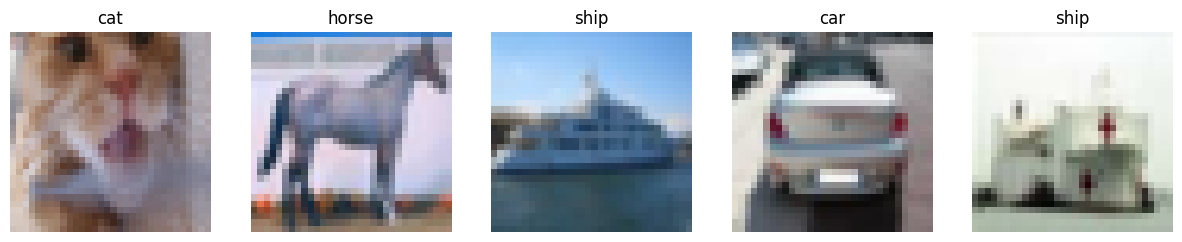

In [ ]:
def visualize_samples(dataloader, classes, num_samples=5):
    # Get a batch of images
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))


    for i in range(num_samples):
        img = images[i] / 2 + 0.5  # unnormalize back to 0,1 range
        npimg = img.numpy()

        # Transpose the image from (C, H, W) to (H, W, C)

        axes[i].imshow(np.transpose(npimg, (1, 2, 0)))
        axes[i].set_title(classes[labels[i]])
        axes[i].axis('off')

    plt.show()

# Run visualization
visualize_samples(train_loader, classes)

## **4) Model 1: Fully Connected Neural Network (FCNN)**

**Architecture**
Create a class `FCNN` with the following constraints:

  * **Input:** 32x32x3 RGB image.
  * **Hidden Layers:** Use at least 3 hidden layers with **ReLU** activation.
  * **Parameters:** The total parameter count should be **greater than 500,000**.
  * **Output:** 10 classes.

**Parameter Count**
Implement a function to count and print the number of trainable parameters.

In [ ]:
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()
        # TODO: Define Linear layers to reach > 500,000 parameters
        # input : 3*32*32 = 3072
        # layer1 : 3072 -> 256
        self.fc1 = nn.Linear(3*32*32, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        # T Flatten input and pass through layers
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


def count_parameters(model):
    # Return total trainable parameters
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Initialize model
fcnn_model = FCNN().to(DEVICE)
print(f"FCNN Parameters: {count_parameters(fcnn_model)}")

FCNN Parameters: 828490



## **5) Training and Evaluation Helper Functions**



**Train Function**

  * Input: model, dataloader, criterion, optimizer.
  * Action: Perform forward pass, loss calculation, backward pass, and optimization.
  * Return: Average loss and Accuracy for the epoch.

**Evaluate Function**

  * Input: model, dataloader, criterion.
  * Action: Perform forward pass (no grad), calculate loss and accuracy.
  * Return: Average loss and Accuracy.



In [ ]:

def train_one_epoch(model, loader, criterion, optimizer):
    # Implement training loop
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad() # zero the parameter gradients
        outputs = model(images) # forward pass
        loss = criterion(outputs, labels)

        loss.backward() # backward pass and optimization
        optimizer.step()


        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

def evaluate(model, loader, criterion):
    # Implement evaluation loop
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0


    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy


## **6) Train FCNN**



1.  Define Optimizer, Learning Rate, and Criterion.
2.  Run the training loop for **10-15 epochs**.
3.  Store Train Loss, Val Loss, Train Acc, and Val Acc for plotting.
4.  Plot the Loss and Accuracy curves.


In [7]:
# TODO: Training Loop
criterion = nn.CrossEntropyLoss() # define optimizer, learning rate and criterion
optimizer = optim.Adam(fcnn_model.parameters(), lr=0.001)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

num_epochs = 12

print("Starting  FCNN Training...")
for epoch in range(num_epochs):

    t_loss , t_acc = train_one_epoch(fcnn_model, train_loader, criterion, optimizer) # train
    v_loss , v_acc = evaluate(fcnn_model, val_loader, criterion) # validate

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)


    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {t_loss:.4f}, Train Acc: {t_acc:.2f}% | "
          f"Val Loss: {v_loss:.4f}, Val Acc: {v_acc:.2f}%")

Starting  FCNN Training...
Epoch [1/12] Train Loss: 1.6627, Train Acc: 40.86% | Val Loss: 1.5324, Val Acc: 45.82%
Epoch [2/12] Train Loss: 1.4476, Train Acc: 48.69% | Val Loss: 1.4458, Val Acc: 48.98%
Epoch [3/12] Train Loss: 1.3427, Train Acc: 52.37% | Val Loss: 1.4085, Val Acc: 51.02%
Epoch [4/12] Train Loss: 1.2550, Train Acc: 55.64% | Val Loss: 1.3609, Val Acc: 53.16%
Epoch [5/12] Train Loss: 1.1806, Train Acc: 58.28% | Val Loss: 1.3700, Val Acc: 52.04%
Epoch [6/12] Train Loss: 1.1113, Train Acc: 60.49% | Val Loss: 1.3778, Val Acc: 53.32%
Epoch [7/12] Train Loss: 1.0451, Train Acc: 62.91% | Val Loss: 1.4199, Val Acc: 52.06%
Epoch [8/12] Train Loss: 0.9898, Train Acc: 65.03% | Val Loss: 1.4508, Val Acc: 51.94%
Epoch [9/12] Train Loss: 0.9323, Train Acc: 66.99% | Val Loss: 1.4077, Val Acc: 53.14%
Epoch [10/12] Train Loss: 0.8748, Train Acc: 68.69% | Val Loss: 1.4713, Val Acc: 52.48%
Epoch [11/12] Train Loss: 0.8311, Train Acc: 70.29% | Val Loss: 1.4669, Val Acc: 53.56%
Epoch [12/12] 

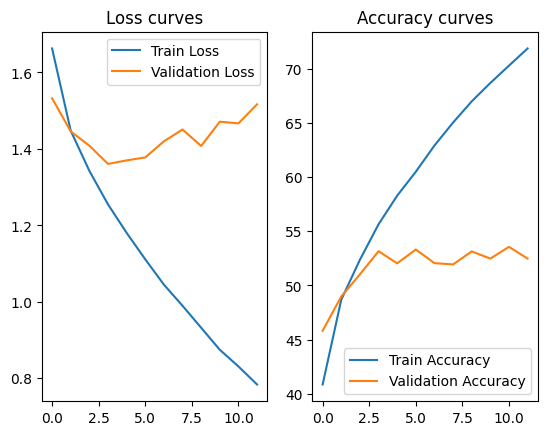

In [8]:
# TODO: Plot Training vs Validation Loss and Accuracy

# plot loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss curves')
plt.legend()


# plot accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy curves')
plt.legend()
plt.show()


## **7) FCNN Analysis**

**Test Set Evaluation**
Evaluate the FCNN on the `test_loader` and print the classification report.

**Confusion Matrix**
Generate and plot a confusion matrix using Seaborn.

**Sample Visualization**
Visualize 3 **Correctly** classified samples and 3 **Incorrectly** classified samples with their Predicted vs. Actual labels.


In [ ]:
# Evaluate on Test Set
test_loss, test_acc = evaluate(fcnn_model, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

# Classification Report
y_true = []
y_pred = []

fcnn_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = fcnn_model(images)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes))


Test Loss: 1.5241, Test Acc: 53.11%
Classification Report:
              precision    recall  f1-score   support

       plane       0.57      0.68      0.62      1000
         car       0.69      0.58      0.63      1000
        bird       0.40      0.42      0.41      1000
         cat       0.35      0.36      0.36      1000
        deer       0.44      0.45      0.45      1000
         dog       0.44      0.39      0.42      1000
        frog       0.59      0.58      0.59      1000
       horse       0.62      0.57      0.59      1000
        ship       0.68      0.63      0.66      1000
       truck       0.55      0.64      0.59      1000

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.53     10000
weighted avg       0.53      0.53      0.53     10000



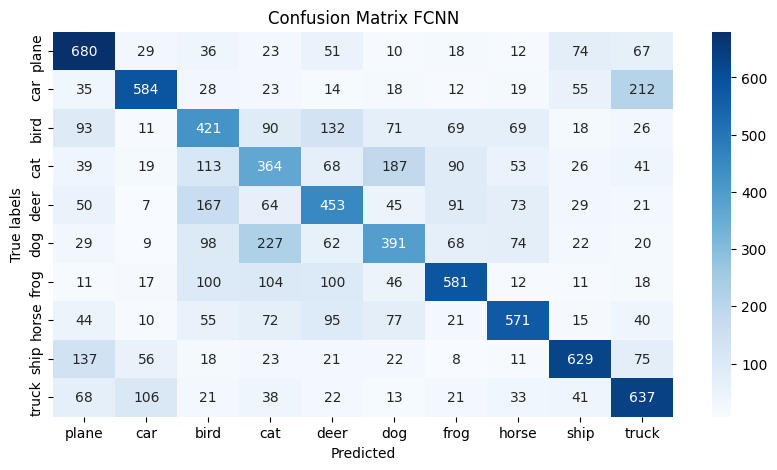

In [ ]:
# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True labels')
plt.title('Confusion Matrix FCNN')
plt.show()

Tota correct: {len(correct_indices)} | Total incorrect: {len(incorrect_indices)}
Correctly classified  samples


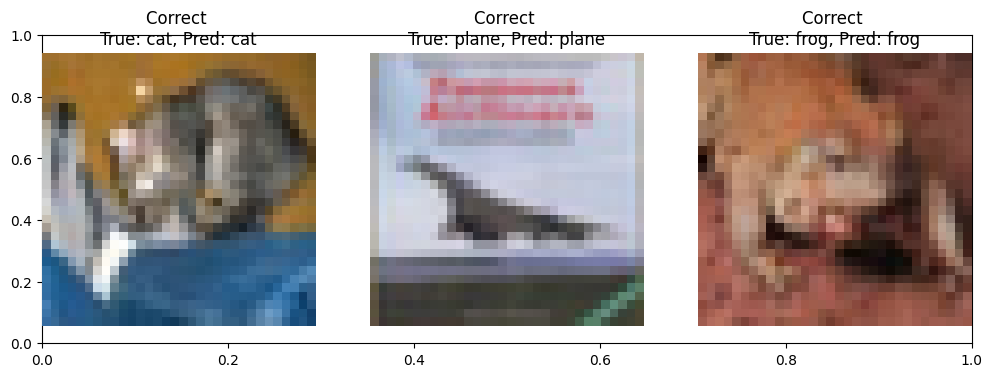

 Incorrectly Classified Samples


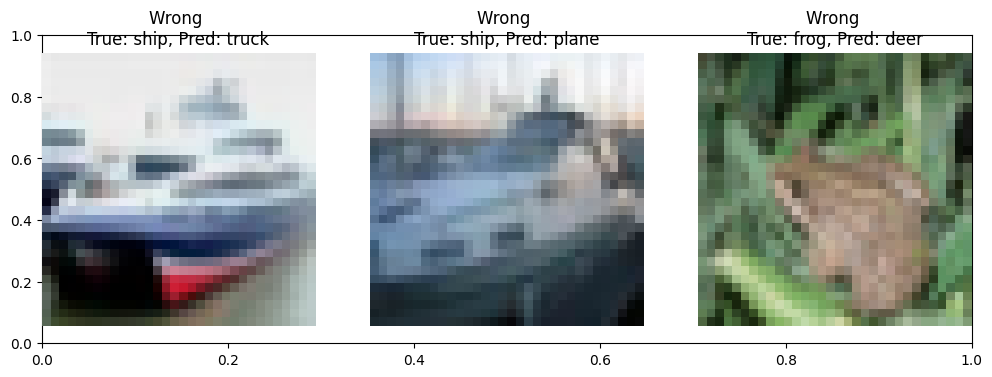

In [ ]:
# Visualize Correct/Incorrect Samples
# identfyig correct and incorrect indices
correct_indices = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t == p]
incorrect_indices = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p]


def show_samples_by_indices(indices, title_prefix, num_samples=3):
    plt.subplots(figsize=(12, 4))

    for i, idx in enumerate(indices[:num_samples]):
        img_tensor, true_label_idx = test_dataset[idx]
        pred_label_idx = y_pred[idx] # use FCNN predictions

        img = img_tensor / 2 + 0.5  # unnormalize
        npimg = img.numpy()

        plt.subplot(1, num_samples, i+1)
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
        plt.title(f"{title_prefix} \nTrue: {classes[true_label_idx]}, Pred: {classes[pred_label_idx]}")
        plt.axis('off')
    plt.show()

print('Tota correct: {len(correct_indices)} | Total incorrect: {len(incorrect_indices)}')
print('Correctly classified  samples')
show_samples_by_indices(correct_indices, "Correct")

print(' Incorrectly Classified Samples')
show_samples_by_indices(incorrect_indices, "Wrong")




## **8) Model 2: Convolutional Neural Network (CNN)**

**Architecture**
Create a class `CNN` with the following constraints:

  * **Input:** 32x32x3 Image.
  * **Layers:** Use `Conv2d`, `MaxPool2d`, `ReLU`, and `Linear` layers.
  * **Parameters:** The total parameter count should be **less than 250,000**.



In [14]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # TODO: Define Convolutional, Pooling, and Linear layers

        # block 1: 3 -> 16 channels
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # reduce dimensions by half

        # block 2: 16 -> 32 channels
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # block 3: 32 -> 64 channels
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        # fully connected layers
        self.fc1 = nn.Linear(64 * 4 * 4, 10) # feaature map size os 64 channels * 4x4



    def forward(self, x):
        # TODO: Implement forward pass
        x = self.pool(F.relu(self.conv1(x))) # block 1 ( 16,16,16)
        x = self.pool(F.relu(self.conv2(x))) # block 2 (32, 8, 8)
        x = self.pool(F.relu(self.conv3(x))) # block 3 (64, 4, 4)

        x = x.view(x.size(0), -1)  # flatten
        x = self.fc1(x)            # output layer
        return x

# Initialize model
cnn_model = SimpleCNN().to(DEVICE)
print(f"CNN Parameters: {count_parameters(cnn_model)}")


CNN Parameters: 33834




## **9) Train CNN**



1.  Define ptimizer and Criterion.
2.  Train the CNN using the **same** `train_one_epoch` and `evaluate` functions defined earlier.
3.  Train for the same number of epochs as FCNN.
4.  Plot Loss and Accuracy curves.



In [ ]:
# Training Loop for CNN (Same as FCNN)
criterion = nn.CrossEntropyLoss() # define optimizer, learning rate and criterion
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

train_losses_cnn, val_losses_cnn = [], []
train_accs_cnn, val_accs_cnn = [], []

num_epochs = 12
print("Starting CNN Training...")

# training loop
for epoch in range(num_epochs):

    t_loss_cnn , t_acc_cnn = train_one_epoch(cnn_model, train_loader, criterion, optimizer_cnn) # train
    v_loss_cnn , v_acc_cnn = evaluate(cnn_model, val_loader, criterion) # validate

    train_losses_cnn.append(t_loss_cnn)
    val_losses_cnn.append(v_loss_cnn)
    train_accs_cnn.append(t_acc_cnn)
    val_accs_cnn.append(v_acc_cnn)


    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {t_loss_cnn:.4f}, Train Acc: {t_acc_cnn:.2f}% | "
          f"Val Loss: {v_loss_cnn:.4f}, Val Acc: {v_acc_cnn:.2f}%")



Starting CNN Training...
Epoch [1/12] Train Loss: 1.5078, Train Acc: 45.94% | Val Loss: 1.2630, Val Acc: 54.34%
Epoch [2/12] Train Loss: 1.1461, Train Acc: 59.62% | Val Loss: 1.1099, Val Acc: 60.74%
Epoch [3/12] Train Loss: 0.9942, Train Acc: 65.29% | Val Loss: 0.9753, Val Acc: 65.42%
Epoch [4/12] Train Loss: 0.8967, Train Acc: 68.83% | Val Loss: 0.9114, Val Acc: 67.94%
Epoch [5/12] Train Loss: 0.8245, Train Acc: 71.50% | Val Loss: 0.8787, Val Acc: 68.38%
Epoch [6/12] Train Loss: 0.7658, Train Acc: 73.56% | Val Loss: 0.8516, Val Acc: 69.20%
Epoch [7/12] Train Loss: 0.7183, Train Acc: 75.12% | Val Loss: 0.7964, Val Acc: 72.14%
Epoch [8/12] Train Loss: 0.6820, Train Acc: 76.29% | Val Loss: 0.8271, Val Acc: 71.04%
Epoch [9/12] Train Loss: 0.6432, Train Acc: 77.66% | Val Loss: 0.7979, Val Acc: 72.78%
Epoch [10/12] Train Loss: 0.6135, Train Acc: 78.83% | Val Loss: 0.8034, Val Acc: 72.74%
Epoch [11/12] Train Loss: 0.5852, Train Acc: 79.84% | Val Loss: 0.7998, Val Acc: 72.32%
Epoch [12/12] Tr

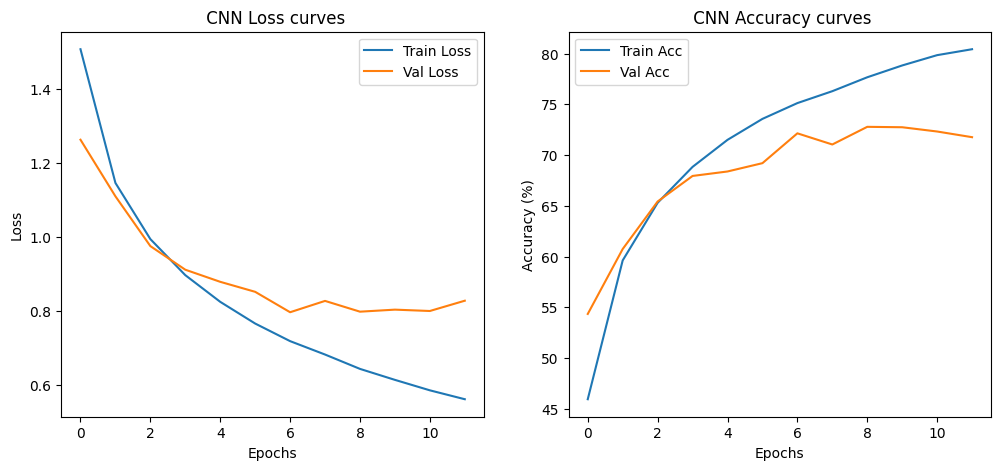

In [ ]:
# Plot Curves
plt.figure(figsize=(12,5))

# plot loss
plt.subplot(1, 2, 1)
plt.plot(train_losses_cnn, label='Train Loss')
plt.plot(val_losses_cnn, label='Val Loss')
plt.title(' CNN Loss curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


# plot accuracy

plt.subplot(1, 2, 2)
plt.plot(train_accs_cnn, label='Train Acc')
plt.plot(val_accs_cnn, label='Val Acc')
plt.title(' CNN Accuracy curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()


plt.show()


## **10) CNN Analysis**

**Test Set Evaluation**
Evaluate the CNN on the `test_loader`.

**Confusion Matrix**
Generate and plot the confusion matrix for the CNN.

**Sample Visualization**
Visualize 3 Correct and 3 Incorrect samples for the CNN.


In [ ]:
# Evaluate CNN on Test Set
test_loss_cnn, test_acc_cnn = evaluate(cnn_model, test_loader, criterion)
print(f" CNN Test Loss: {test_loss_cnn:.4f}, Test Acc: {test_acc_cnn:.2f}%")


 CNN Test Loss: 0.8452, Test Acc: 71.90%


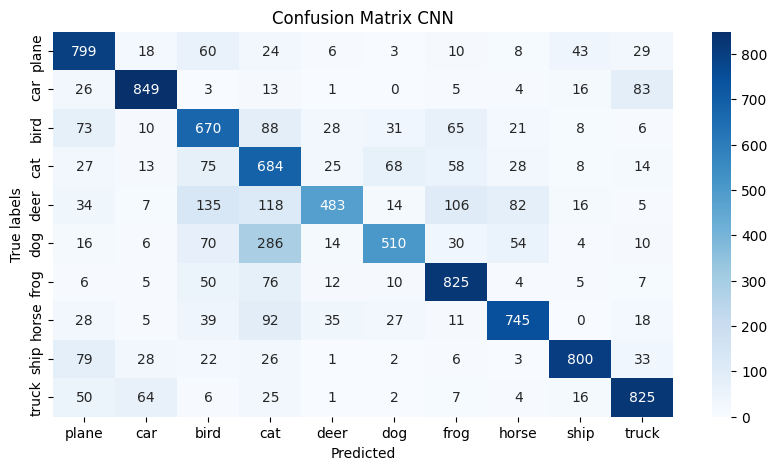

In [ ]:
# Confusion Matrix for CNN
y_true_cnn = []
y_pred_cnn = []


cnn_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs.data, 1)

        y_true_cnn.extend(labels.cpu().numpy())
        y_pred_cnn.extend(predicted.cpu().numpy())

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(10,5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True labels')
plt.title('Confusion Matrix CNN')
plt.show()

CNN correctly classified  samples:


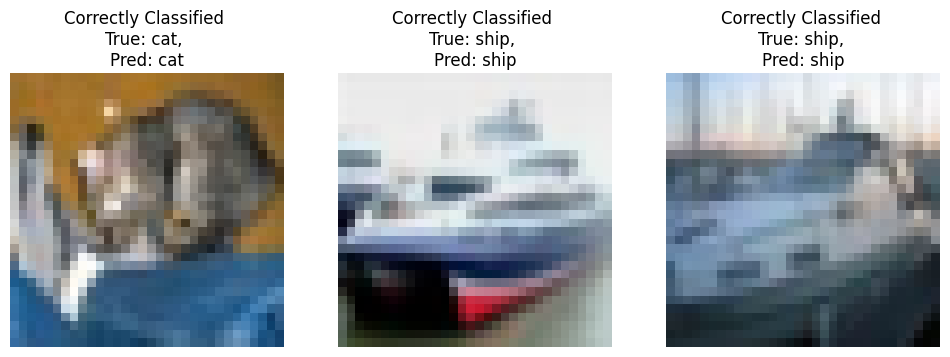

Incorrectly classified samples:


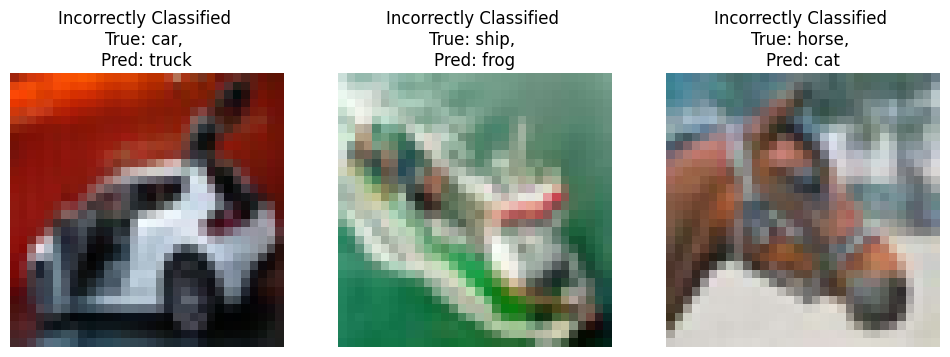

In [ ]:
# Visualize Correct/Incorrect Samples
correct_idx_cnn = [i for i, (t, p) in enumerate(zip(y_true_cnn, y_pred_cnn)) if t == p]
incorrect_idx_cnn = [i for i, (t, p) in enumerate(zip(y_true_cnn, y_pred_cnn)) if t != p]

def show_cnn_samples(indices, title_prefix):
    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(indices[:3]):
        img_tensor, true_label = test_dataset[idx]
        pred_label = y_pred_cnn[idx]

        img = img_tensor / 2 + 0.5  # unnormalize
        npimg = img.numpy()

        plt.subplot(1,3, i+1)
        plt.imshow(np.transpose(npimg, (1, 2, 0)))
        plt.title(f"{title_prefix} \nTrue: {classes[true_label]}, \nPred: {classes[pred_label]}")
        plt.axis('off')
    plt.show()


print('CNN correctly classified  samples:')
show_cnn_samples(correct_idx_cnn, 'Correctly Classified')

print('Incorrectly classified samples:')
show_cnn_samples(incorrect_idx_cnn , 'Incorrectly Classified')



## **11) Final Analysis & Conclusion**


Compare the performance of the FCNN (approx. 500K parameters) vs. the CNN (approx. 250K parameters).

1.  Which model performed better on the Test set?
   The CNN performed significantly better than the (Fully Connected Neural Network)  FCNN. As the results show that CNN has test Accuracy of 71.90% and loss is 0.8452, while on the other hand, FCNN has test accuracy of 53.11% and loss 1.5241. These results show that the CNN clearly outperformed the FCNN by approximately 18.8 percentage points in accuracy.

2.  Why did the CNN perform better (or worse) despite having significantly fewer parameters?
   The CNN performed better because it is specifically designed to process grid-like data i.e. images and learn features more efficiently than an FCNN. FCNNs flatten the input image into a 1D vector, destroying the spatial structure. While CNNs use kernels to scan small local regions of the image, allowing them to capture spatial relationships like edges, textures, and shapes.
   Also, in a CNN, the same filter is applied across the entire image. If the model learns to detect a vertical edge in the top-left corner, it can detect that same edge in the bottom-right corner using the same parameters. On the other hand FCNN have to learn separate parameters for the same feature at every different location in the image, which is highly inefficient. Therefore CNN, despite with fewer parameters and built-in inductive biases for images, generalized much better than FCNN.

# **Part B - Transfer Learning**

In this part, will train two models on the **Chest X-ray Pneumonia dataset** (Normal vs Pneumonia):
1. A small CNN trained from scratch
2. A pretrained ResNet-18 fine-tuned on the same dataset

### **Dataset Instructions**

**⚠️ IMPORTANT: manually download the dataset before starting this section.**

1. Download the dataset from Kaggle: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
2. Extract the downloaded archive
3. Place the extracted folder in your working directory (same location as this notebook)
4. The folder structure should look like:
   ```
   chest_xray/
   ├── train/
   │   ├── NORMAL/
   │   └── PNEUMONIA/
   ├── val/
   │   ├── NORMAL/
   │   └── PNEUMONIA/
   └── test/
       ├── NORMAL/
       └── PNEUMONIA/
   ```

### **Goals:**
- Build & train a simple CNN from scratch
- Load & fine-tune a pretrained ResNet-18
- Compare both models based on accuracy, loss curves, training speed, and generalization
- Write a final analysis comparing both approaches

## **1) Data Loading**

* Load the Chest X-ray dataset and prepare DataLoaders for train, validation, and test sets.**


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# resize the images to 224x224 for  ResNet compatibility
xray_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

data_dir = '/content/drive/MyDrive/Colab Notebooks/data/chest_xray'
try:

    train_xr = ImageFolder(f'{data_dir}/train', transform=xray_transforms)
    val_xr = ImageFolder(f'{data_dir}/val', transform=xray_transforms)
    test_xr = ImageFolder(f'{data_dir}/test', transform=xray_transforms)

    batch_size_xr = 32
    train_loader_xr = DataLoader(train_xr, batch_size=batch_size_xr, shuffle=True)
    val_loader_xr = DataLoader(val_xr, batch_size=batch_size_xr, shuffle=False)
    test_loader_xr = DataLoader(test_xr, batch_size=batch_size_xr, shuffle=False)

    print(f"Classes: {train_xr.classes}")

except Exception as e:
    print(f"Data Loading Error: {e}")


Classes: ['NORMAL', 'PNEUMONIA']


## **2) Model A — CNN From Scratch**

**Define your own small CNN architecture for training from scratch.**

In [22]:
class XRayCNN(nn.Module):
    def __init__(self):
        super(XRayCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1) # block 1
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d( 32, 64,  3, padding=1) # block 2

        self.conv3 = nn.Conv2d(64, 128, 3, padding= 1) # block 3

        self.conv4 = nn.Conv2d(128, 256, 3, padding =1 ) # block 4


        self.fc1 = nn.Linear(256 * 14 * 14 , 512)
        self.fc2 = nn.Linear(512, 2) # assuming binary classification

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))

        x = x.view(x.size(0), -1) # flatten

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## **3) Train Scratch Model**
**Train CNN from scratch and record training/validation accuracy for multiple epochs.**

In [24]:
model_a = XRayCNN().to(DEVICE)  # initialize model
optimizer_a = optim.Adam(model_a.parameters(), lr=0.001)
criterion_xr = nn.CrossEntropyLoss()
val_acc_a = []

print(f"Model A initialized. Parameter count: {sum(p.numel() for p in model_a.parameters() if p.requires_grad)}")
print("Training Scratch Model...")


for epoch in range(10):  # train for 10 epochs
    avg_loss, t_acc = train_one_epoch(model_a, train_loader_xr, criterion_xr, optimizer_a)
    _, v_acc = evaluate(model_a, val_loader_xr, criterion_xr)

    val_acc_a.append(v_acc)
    print(f"Epoch [{epoch+1}]: Train Loss: {avg_loss:.4f}, Train Acc: {t_acc:.2f}%, Val Acc: {v_acc:.2f}%")

Model A initialized. Parameter count: 26080066
Training Scratch Model...
Epoch [1]: Train Loss: 0.1886, Train Acc: 92.85%, Val Acc: 56.25%
Epoch [2]: Train Loss: 0.0894, Train Acc: 96.57%, Val Acc: 100.00%
Epoch [3]: Train Loss: 0.0686, Train Acc: 97.60%, Val Acc: 75.00%
Epoch [4]: Train Loss: 0.0440, Train Acc: 98.33%, Val Acc: 81.25%
Epoch [5]: Train Loss: 0.0493, Train Acc: 98.54%, Val Acc: 81.25%
Epoch [6]: Train Loss: 0.0303, Train Acc: 98.87%, Val Acc: 93.75%
Epoch [7]: Train Loss: 0.0200, Train Acc: 99.14%, Val Acc: 87.50%
Epoch [8]: Train Loss: 0.0191, Train Acc: 99.35%, Val Acc: 81.25%
Epoch [9]: Train Loss: 0.0107, Train Acc: 99.65%, Val Acc: 93.75%
Epoch [10]: Train Loss: 0.0186, Train Acc: 99.21%, Val Acc: 87.50%


## **4) Model B — Transfer Learning with ResNet-18**
**Load a pretrained ResNet-18, freeze its layers, and replace the final classifier.**

In [25]:
from torchvision import models

model_b = models.resnet18(pretrained=True) # pretrained ResNet18

for param in model_b.parameters():
    param.requires_grad = False  # freeze all layers

# replace classifier
num_ftrs = model_b.fc.in_features
model_b.fc = nn.Linear(num_ftrs, 2)


model_b = model_b.to(DEVICE)
print (" Model B (Resnet) intialized")




/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 216MB/s]

 Model B (Resnet) intialized


## **5) Train ResNet Model**
**Train the ResNet model and record training/validation accuracy.**

In [26]:
optimizer_b = optim.Adam(model_b.fc.parameters(), lr=0.001)  # only train fc layer
val_acc_b = []

print("Training ResNet Model...")
for epoch in range(10):  # train for 10 epochs
    _, t_acc = train_one_epoch(model_b, train_loader_xr, criterion_xr, optimizer_b)
    _, v_acc = evaluate(model_b, val_loader_xr, criterion_xr)
    val_acc_b.append(v_acc)
    print(f"Epoch [{epoch+1}]: Val Acc: {v_acc:.2f}%")

Training ResNet Model...
Epoch [1]: Val Acc: 68.75%
Epoch [2]: Val Acc: 75.00%
Epoch [3]: Val Acc: 75.00%
Epoch [4]: Val Acc: 75.00%
Epoch [5]: Val Acc: 75.00%
Epoch [6]: Val Acc: 81.25%
Epoch [7]: Val Acc: 68.75%
Epoch [8]: Val Acc: 75.00%
Epoch [9]: Val Acc: 68.75%
Epoch [10]: Val Acc: 81.25%


## **6) Plot Comparison**
**Plot training and validation accuracy of both models to compare performance.**

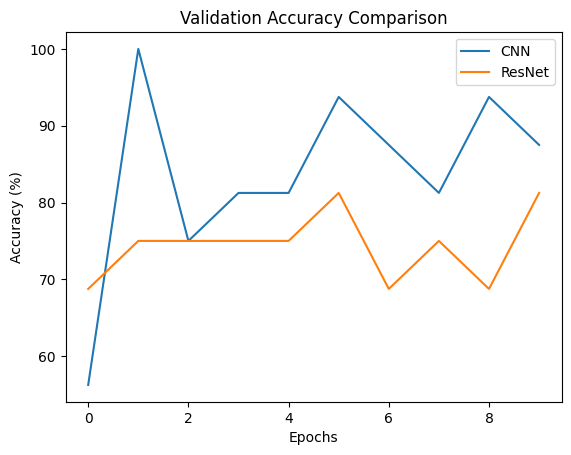

In [27]:
plt.plot(val_acc_a, label='CNN')
plt.plot(val_acc_b, label='ResNet')
plt.legend()
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.show()


# **7) Test Data Comparison**

**Task: Compare the accuracies of both models on the test set**

In [28]:
_, test_acc_a = evaluate(model_a, test_loader_xr, criterion_xr)
_, test_acc_b = evaluate(model_b, test_loader_xr, criterion_xr)
print(f"Model A CNN : {test_acc_a:.2f}%")
print(f"Model B Resnet: {test_acc_b:.2f}%")

Model A CNN : 75.00%
Model B Resnet: 82.69%


## **8) Final Analysis & Conclusion**




- Why the pretrained model outperformed the scratch model

The pretrained ResNet-18 (Model B) comes with weights that have already been optimized on ImageNet whereas Model A (CNN) starts from random initialization. Moreover, as the results show the Model A (CNN) reached a training accuracy of 99.21% by Epoch 10, but its validation accuracy fluctuated wildly (dropping to 56%, jumping to 100%, then settling around 87%). This massive gap and volatility indicate overfitting—the model and model is memorizing the specific training examples rather than learning general features. While model B (ResNet) typically shows more stable convergence because its internal feature extractors are fixed (frozen). It only needs to learn the final decision boundary, leading to more consistent performance on unseen data.

- Why transfer learning is essential for small datasets

Convolutional neural networks are extremely "data-hungry." They require vast amounts of diverse data to tune millions of parameters effectively. So, when we train a huge model on a small dataset from scratch, the model has enough capacity to simply memorize every pixel in training data. On the other hand,  transfer learning mitigates this by freezing the vast majority of parameters, forcing the model to rely on pre-learned, than creating new ones

- What features ImageNet CNNs learn that transfer to medical images

 The features that CNN learn universally and that apply to any image, including X-rays are majorly detecting vertical, horizontal, and diagonal lines (essential for identifying rib cages and lung boundaries).Also identifying gradients and surface patterns which are important in order to distinguish  between clear lung tissue and the cloudy i.e the pneumonia one.

- Which model generalized better and why?

The model b (i.e. Pretrained ResNet) performs better because it utilized feature extractors that have been proven to work on a wide variety of data and it didn't have to learn from scratch and has better generalization, on the other hand model A (CNN) suffered from poor generalization and even though it achieved near-perfect performance on the training data but struggled on validation data and hence learned the noise of the training data
